# Market return and risk analysis

Return, volatility and correlation behaviour across the deal timeline, and the arbitrage spread series that the later portfolio and derivatives notebooks build on.

In [1]:

import sys, warnings
sys.path.insert(0, r"/Users/shaan/Desktop/FAM/sunpharma-organon-merger-arbitrage")
warnings.filterwarnings("ignore")

from src import config as cfg, data, risk, viz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.width", 160)
viz.apply_style()

prices = data.load_prices()
panel = data.close_panel(prices)
returns = data.log_returns(panel)  # union-calendar returns - fine for cross-ticker correlation,
                                    # NOT used for any single-ticker series below (see note)


## Volatility regimes

Organon's realised volatility across four periods defined by the deal timeline: the multi-year baseline, the run-up into the leak, the leak-to-announcement window, and the post-announcement period once the price pinned to the deal.

Computed from Organon's own trading calendar rather than the multi-ticker panel above: the panel indexes on the union of every ticker's dates, so `.shift(1)` there shifts by a row in that unioned calendar, not by one actual OGN trading day - any NSE-only date sitting between two real OGN sessions would silently turn a legitimate OGN return into a dropped observation. That is a safe failure (NaN, not a wrong number) but it under-counts real trading days, so single-ticker series are built directly from each ticker's own price history throughout this notebook.

In [2]:

ogn_ret = np.log(prices[cfg.TARGET]["Close"] / prices[cfg.TARGET]["Close"].shift(1)).dropna()

regimes = {
    "2021-2025 baseline": ("2021-01-01", "2025-12-31"),
    "pre-leak (2025 H2)": ("2025-07-01", "2026-01-15"),
    "leak to announcement": ("2026-01-16", "2026-04-24"),
    "post-announcement": ("2026-04-28", "2026-12-31"),
}

rows = []
for label, (start, end) in regimes.items():
    seg = ogn_ret.loc[start:end]
    rows.append({"period": label, "n_days": len(seg), "annualised_vol": risk.annualised_vol(seg)})
vol_table = pd.DataFrame(rows).set_index("period")
vol_table["annualised_vol"] = vol_table["annualised_vol"].round(4)
vol_table.to_csv(cfg.OUT_TABLES / "volatility_regimes.csv")
vol_table


,n_days,annualised_vol
period,,
2021-2025 baseline,1163,0.4478
pre-leak (2025 H2),138,0.5802
leak to announcement,68,0.9418
post-announcement,69,0.0446


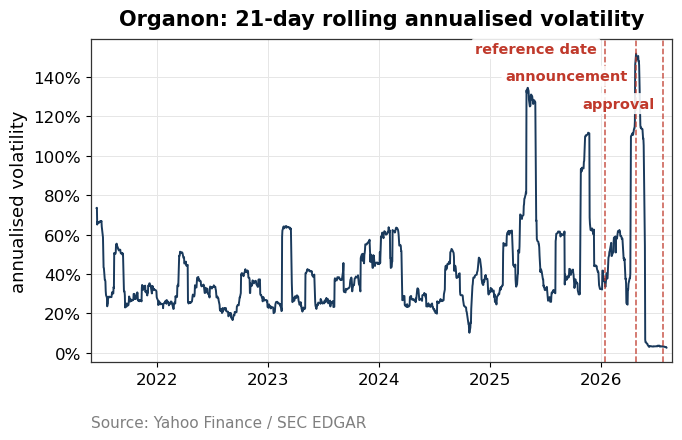

In [3]:

from matplotlib.ticker import PercentFormatter

fig, ax = plt.subplots(figsize=viz.FIG_STD)
rolling = risk.rolling_vol(ogn_ret, window=21)
ax.plot(rolling.index, rolling.values * 100, color=viz.PALETTE["primary"], linewidth=1.4)

# the three event dates fall within ~6 months of each other; drawing all three
# labels at one height overprints them, so they are staggered across two rows
viz.stagger_event_labels(ax, [
    (cfg.DEAL["leak_date"], "reference date"),
    (cfg.DEAL["announcement_date"], "announcement"),
    (cfg.DEAL["shareholder_approval_date"], "approval"),
])

ax.set_title("Organon: 21-day rolling annualised volatility")
ax.set_ylabel("annualised volatility")
ax.yaxis.set_major_formatter(PercentFormatter())
ax.margins(x=0.01)
viz.source_note(ax)
viz.save_chart(fig, "ogn_rolling_volatility", cfg.OUT_CHARTS)
plt.show()


## Correlation matrix

In [4]:

corr_set = [cfg.TARGET, cfg.ACQUIRER, cfg.US_INDEX, cfg.IN_INDEX, cfg.VIX]
corr = returns[corr_set].corr()
corr.round(3).to_csv(cfg.OUT_TABLES / "correlation_matrix.csv")

# the calendar-aligned return panel is the shared input behind the correlation
# matrix here and the regressions in the event-study and portfolio notebooks -
# persisted so those results can be reproduced without re-deriving it
returns[corr_set].dropna().to_csv(cfg.DATA_PROCESSED / "returns_panel_aligned.csv")
corr.round(3)


,OGN,SUNPHARMA.NS,^GSPC,^NSEI,^VIX
OGN,1.000,0.002,0.283,0.057,-0.220
SUNPHARMA.NS,0.002,1.000,0.045,0.381,-0.042
^GSPC,0.283,0.045,1.000,0.194,-0.771
^NSEI,0.057,0.381,0.194,1.000,-0.172
^VIX,-0.220,-0.042,-0.771,-0.172,1.000


## The arbitrage spread

Spread = (offer - price) / price, i.e. the annualisable return to holding OGN through to the offer price. Bounded by construction as the deal closes, so this is a description of the series, not a claim that it behaves like a free-floating asset return.

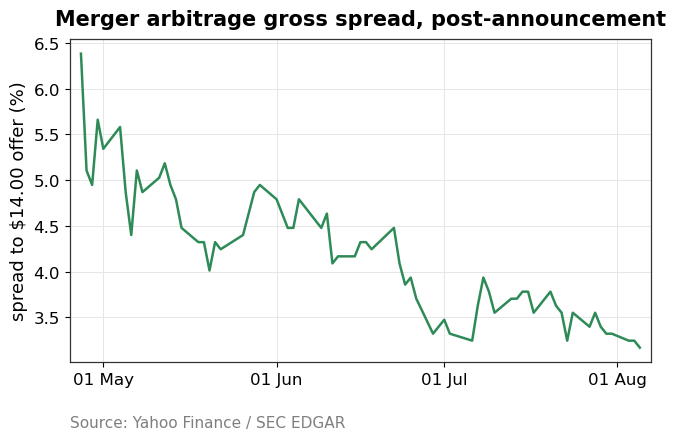

spread on announcement day+1 : 5.11%
spread today                 : 3.17%
spread mean (post-ann.)      : 4.19%
spread std (post-ann.)       : 0.70%


In [5]:

# built from OGN's own trading calendar, not the multi-ticker panel - the
# panel indexes on the UNION of all tickers' dates (NSE and NYSE don't share
# a calendar), which would silently NaN the most recent OGN observation on
# any date NSE traded but NYSE didn't
offer = cfg.DEAL["offer_price_usd"]
ogn_close_own = prices[cfg.TARGET]["Close"]
spread = (offer - ogn_close_own) / ogn_close_own
spread_post = spread.loc[spread.index >= pd.Timestamp(cfg.DEAL["announcement_date"])].dropna()

import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=viz.FIG_STD)
ax.plot(spread_post.index, spread_post.values * 100, color=viz.PALETTE["accent"], linewidth=1.8)
ax.set_title("Merger arbitrage gross spread, post-announcement")
ax.set_ylabel("spread to $14.00 offer (%)")
# monthly ticks in a short format: the default daily auto-ticks print full
# ISO dates that collide into each other once the figure is scaled down for
# the deck, which is where this chart is used
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.margins(x=0.02)
viz.source_note(ax)
viz.save_chart(fig, "arb_spread_series", cfg.OUT_CHARTS)
plt.show()

print(f"spread on announcement day+1 : {spread_post.iloc[1]:.2%}")
print(f"spread today                 : {spread_post.iloc[-1]:.2%}")
print(f"spread mean (post-ann.)      : {spread_post.mean():.2%}")
print(f"spread std (post-ann.)       : {spread_post.std():.2%}")


## Stationarity: ADF on the spread

The spread is mechanically converging toward zero as the deal approaches close - it is not a stationary or non-stationary economic series in the usual sense, and an ADF result here should not be read as evidence of mean-reverting arbitrage opportunity.

In [6]:

adf_spread = risk.adf_test(spread_post)
print(f"ADF statistic : {adf_spread['stat']:.3f}")
print(f"p-value        : {adf_spread['p_value']:.4f}")
print(f"stationary at 5%: {adf_spread['stationary_at_5pct']}")
print("\n(bounded, mechanically-converging series - see note above on interpretation)")


ADF statistic : -3.064
p-value        : 0.0293
stationary at 5%: True

(bounded, mechanically-converging series - see note above on interpretation)


## ARCH effects

Ljung-Box test on squared returns, run separately pre- and post-announcement, since fitting one model across the volatility break would blend two different regimes.

In [7]:

pre_ann = ogn_ret.loc[:"2026-04-24"]
post_ann = ogn_ret.loc["2026-04-28":]

arch_pre = risk.arch_lm_test(pre_ann, lags=12)
arch_post = risk.arch_lm_test(post_ann, lags=12)

print("pre-announcement:")
print(f"  Ljung-Box stat={arch_pre['lb_stat']:.2f}  p={arch_pre['lb_pvalue']:.4f}  ARCH effect present: {arch_pre['arch_effect_present']}")
print("post-announcement:")
print(f"  Ljung-Box stat={arch_post['lb_stat']:.2f}  p={arch_post['lb_pvalue']:.4f}  ARCH effect present: {arch_post['arch_effect_present']}")


pre-announcement:
  Ljung-Box stat=78.59  p=0.0000  ARCH effect present: True
post-announcement:
  Ljung-Box stat=15.19  p=0.2314  ARCH effect present: False


## Summary

In [8]:

summary = pd.Series({
    "vol_baseline": vol_table.loc["2021-2025 baseline", "annualised_vol"],
    "vol_pre_leak": vol_table.loc["pre-leak (2025 H2)", "annualised_vol"],
    "vol_leak_to_announcement": vol_table.loc["leak to announcement", "annualised_vol"],
    "vol_post_announcement": vol_table.loc["post-announcement", "annualised_vol"],
    "spread_today": spread_post.iloc[-1],
    "corr_ogn_sunpharma": corr.loc[cfg.TARGET, cfg.ACQUIRER],
    "adf_pvalue_spread": adf_spread["p_value"],
    "arch_effect_pre_announcement": arch_pre["arch_effect_present"],
    "arch_effect_post_announcement": arch_post["arch_effect_present"],
})
summary.to_csv(cfg.DATA_FINAL / "risk_summary.csv", header=["value"])
summary


vol_baseline                       0.4478
vol_pre_leak                       0.5802
vol_leak_to_announcement           0.9418
vol_post_announcement              0.0446
spread_today                     0.031688
corr_ogn_sunpharma               0.001683
adf_pvalue_spread                0.029314
arch_effect_pre_announcement         True
arch_effect_post_announcement       False
dtype: object